# 03 · Sample Efficiency Analysis

Loads all training histories, offline eval results, and closed-loop rollout JSONs from `artifacts/` and produces the paper figures.

| # | Section | Output |
|---|---------|--------|
| 1 | Data loading & configuration | in-memory dicts |
| 2 | Open-loop summary table | printed table |
| 3 | Diagnostic: epoch consistency check | printed report |
| 4 | Figure 1: MSE + NLL vs. training data fraction | `artifacts/sample_efficiency_combined.pdf` |
| 5 | Figure 2: Validation-NLL learning curves | `artifacts/sample_efficiency_learning_curves.pdf` |
| 6 | Figure 5: PointMaze closed-loop sample efficiency | `artifacts/sample_efficiency_pointmaze_closedloop.pdf` |

> **Kernel:** `.venv (Python 3.14)` is fine here — no MuJoCo needed.  
> PointMaze closed-loop results are pre-computed by `02_pointmaze_eval.ipynb` (Python 3.12 kernel) and read from `artifacts/sample_efficiency_pointmaze_closedloop_pooled.json`.

## 1. Data Loading & Configuration

Loads training histories, offline eval results, baselines, and the pooled PointMaze closed-loop JSON.  
`PM_CLOSEDLOOP` points to the **pooled** artifact (40 trials/fraction, two seed families) with fallback to the original 20-trial file.

In [1]:
import json
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ART = Path('artifacts')
# Use pooled JSON (original 20 trials + alt-seed 20 trials = 40 trials per fraction)
PM_CLOSEDLOOP = ART / 'sample_efficiency_pointmaze_closedloop_pooled.json'
# Fall back to original if pooled not yet available
if not PM_CLOSEDLOOP.exists():
    PM_CLOSEDLOOP = ART / 'sample_efficiency_pointmaze_closedloop.json'
    print(f"[INFO] Pooled JSON not found; using original: {PM_CLOSEDLOOP}")
else:
    print(f"[INFO] Using pooled JSON: {PM_CLOSEDLOOP}")

# ── Fraction registry (basis-points tag → float fraction) ──────────────────
FRAC_TAGS = {
    'f00100bp': 0.01,
    'f00215bp': 0.021544,
    'f00464bp': 0.046416,
    'f01000bp': 0.100,
    'f02154bp': 0.215443,
    'f04642bp': 0.464159,
    'f10000bp': 1.0,
}
SEED = 'seed7'

TASK_KEYS = {
    'pusht':           {'hist_key': 'pusht',           'label': 'Push-T',    'n_demos_total': 206},
    'pointmaze_umaze': {'hist_key': 'pointmaze_umaze', 'label': 'PointMaze', 'n_demos_total': 100},
}

# ── Load training histories ─────────────────────────────────────────────────
histories = {}   # (task_key, frac_tag) -> dict
for task_key in TASK_KEYS:
    for frac_tag in FRAC_TAGS:
        p = ART / f'training_history_{task_key}_sampleeff_{frac_tag}_{SEED}.json'
        if p.exists():
            with open(p) as f:
                histories[(task_key, frac_tag)] = json.load(f)

# ── Load offline eval results ───────────────────────────────────────────────
evals = {}   # (task_key, frac_tag) -> dict
for task_key in TASK_KEYS:
    for frac_tag in FRAC_TAGS:
        p = ART / f'eval_results_{task_key}_sampleeff_{frac_tag}_{SEED}.json'
        if p.exists():
            with open(p) as f:
                evals[(task_key, frac_tag)] = json.load(f)

# ── Load full-dataset baselines ─────────────────────────────────────────────
BASELINE_PATHS = {
    'pusht':           ART / 'eval_results_pusht_fair_halfparam_deterministic_clip.json',
    'pointmaze_umaze': ART / 'eval_results_pointmaze_umaze_fair_halfparam_deterministic_clip_120epochs.json',
}
baselines = {}
for task_key, path in BASELINE_PATHS.items():
    if path.exists():
        with open(path) as f:
            baselines[task_key] = json.load(f)

print(f'Training histories loaded: {len(histories)}')
print(f'Eval results loaded:       {len(evals)}')
print(f'Baselines loaded:          {len(baselines)}')
for k in sorted(evals.keys()):
    print(f'  {k[0]:25s}  {k[1]}')

missing_eval = [
    (task_key, frac_tag)
    for task_key in TASK_KEYS
    for frac_tag in FRAC_TAGS
    if (task_key, frac_tag) not in evals and (task_key, frac_tag) in histories
]
if missing_eval:
    print('\nMissing eval artifacts (history exists):')
    for task_key, frac_tag in missing_eval:
        print(f'  {task_key:25s}  {frac_tag}')


[INFO] Using pooled JSON: artifacts/sample_efficiency_pointmaze_closedloop_pooled.json
Training histories loaded: 14
Eval results loaded:       14
Baselines loaded:          2
  pointmaze_umaze            f00100bp
  pointmaze_umaze            f00215bp
  pointmaze_umaze            f00464bp
  pointmaze_umaze            f01000bp
  pointmaze_umaze            f02154bp
  pointmaze_umaze            f04642bp
  pointmaze_umaze            f10000bp
  pusht                      f00100bp
  pusht                      f00215bp
  pusht                      f00464bp
  pusht                      f01000bp
  pusht                      f02154bp
  pusht                      f04642bp
  pusht                      f10000bp


## 2. Open-Loop Summary Table

Builds a tidy DataFrame of all offline eval metrics (NLL, best-of-10 MSE) across tasks and fractions.

In [3]:
# ── Build summary dataframe ─────────────────────────────────────────────────
rows = []
for (task_key, frac_tag), ev in evals.items():
    frac = FRAC_TAGS[frac_tag]
    n_total = TASK_KEYS[task_key]['n_demos_total']
    label   = TASK_KEYS[task_key]['label']

    lr = ev['liquid_results']
    dr = ev['diffusion_results']

    rows.append({
        'task':         label,
        'task_key':     task_key,
        'frac_tag':     frac_tag,
        'fraction':     frac,
        'pct':          round(frac * 100, 2),
        'n_demos':      int(round(frac * n_total)),
        'is_baseline':  False,
        'baseline_note': '',
        # Liquid
        'liq_nll':          lr['exact_nll'],
        'liq_mse_best10':   lr['k_metrics']['10']['best_of_k_mse'],
        'liq_mse_det':      lr['deterministic']['mse'],
        'liq_latency_ms':   lr['k_sample_ms'],
        'liq_per_ex_mse':   lr['k_metrics']['10']['per_example_best_of_k_mse'],
        # Diffusion
        'diff_nll':         dr['proxy_nll'],
        'diff_mse_best10':  dr['k_metrics']['10']['best_of_k_mse'],
        'diff_mse_det':     dr.get('proxy_deterministic', {}).get('mse', np.nan),
        'diff_latency_ms':  dr['k_sample_ms'],
        'diff_per_ex_mse':  dr['k_metrics']['10']['per_example_best_of_k_mse'],
    })

df = pd.DataFrame(rows).sort_values(['task_key', 'fraction']).reset_index(drop=True)

# Add 100% baseline for both tasks when sample-eff eval at 100% is missing.
# For PointMaze this is marked as reference-only because it comes from the
# fair_halfparam_deterministic_clip run, not the sampleeff_* tag.
for task_key, bev in baselines.items():
    label = TASK_KEYS[task_key]['label']
    lr, dr = bev['liquid_results'], bev['diffusion_results']

    has_sampleeff_100 = (
        (task_key, 'f10000bp') in evals
        and np.isclose(FRAC_TAGS.get('f10000bp', np.nan), 1.0)
    )
    if has_sampleeff_100:
        continue

    baseline_note = 'reference-only (different run tag)' if task_key == 'pointmaze_umaze' else ''
    df = pd.concat([df, pd.DataFrame([{
        'task': label, 'task_key': task_key, 'frac_tag': 'f10000bp',
        'fraction': 1.0, 'pct': 100.0,
        'n_demos': TASK_KEYS[task_key]['n_demos_total'],
        'is_baseline': True,
        'baseline_note': baseline_note,
        'liq_nll':          lr['exact_nll'],
        'liq_mse_best10':   lr['k_metrics']['10']['best_of_k_mse'],
        'liq_mse_det':      lr['deterministic']['mse'],
        'liq_latency_ms':   lr['k_sample_ms'],
        'liq_per_ex_mse':   lr['k_metrics']['10']['per_example_best_of_k_mse'],
        'diff_nll':         dr['proxy_nll'],
        'diff_mse_best10':  dr['k_metrics']['10']['best_of_k_mse'],
        'diff_mse_det':     dr.get('proxy_deterministic', {}).get('mse', np.nan),
        'diff_latency_ms':  dr['k_sample_ms'],
        'diff_per_ex_mse':  dr['k_metrics']['10']['per_example_best_of_k_mse'],
    }])], ignore_index=True)

df = df.sort_values(['task_key', 'fraction']).reset_index(drop=True)

# ── Print summary table ─────────────────────────────────────────────────────
cols = ['task', 'pct', 'n_demos', 'is_baseline', 'baseline_note', 'liq_nll', 'liq_mse_best10', 'diff_nll', 'diff_mse_best10']
print(df[cols].to_string(index=False, float_format='{:.5f}'.format))

if ((df['task_key'] == 'pointmaze_umaze') & (df['fraction'] == 1.0) & (df['is_baseline'])).any():
    print('\nPointMaze 100% uses reference baseline (fair_halfparam_deterministic_clip), because sampleeff f10000 eval artifact is missing.')


     task       pct  n_demos  is_baseline baseline_note   liq_nll  liq_mse_best10  diff_nll  diff_mse_best10
PointMaze   1.00000        1        False                -2.30329         0.42946  -1.84822          0.83003
PointMaze   2.15000        2        False                -3.14135         0.20257  -1.50443          0.62227
PointMaze   4.64000        5        False                -5.34632         0.04684  -2.34149          0.50385
PointMaze  10.00000       10        False                -7.44131         0.02555  -3.98737          0.38762
PointMaze  21.54000       22        False                -7.88349         0.01520  -6.54661          0.17597
PointMaze  46.42000       46        False               -11.25930         0.01626  -6.74595          0.01882
PointMaze 100.00000      100        False               -11.01718         0.01459  -8.65252          0.00869
   Push-T   1.00000        2        False                -3.30618         0.00405  -1.50534          0.52363
   Push-T   2.15000

## 3. Diagnostic: Epoch Consistency Check

Verifies that every offline eval artifact was produced at the correct final training epoch (no stale cached results).

In [4]:
# ── Diagnostic: Check for training/eval mismatches ──────────────────────────
print("\n" + "="*80)
print("DIAGNOSTIC: Training History vs Eval Epochs")
print("="*80)

mismatches = []
for task_key in TASK_KEYS:
    for frac_tag in FRAC_TAGS:
        # Check sample-eff runs
        hist_p = ART / f'training_history_{task_key}_sampleeff_{frac_tag}_{SEED}.json'
        eval_p = ART / f'eval_results_{task_key}_sampleeff_{frac_tag}_{SEED}.json'
        
        if hist_p.exists() and eval_p.exists():
            with open(hist_p) as f:
                hist = json.load(f)
            with open(eval_p) as f:
                ev = json.load(f)
            
            hist_epochs = len(hist['liquid_val_nll'])
            eval_epochs = ev.get('epochs_completed', None)
            
            if eval_epochs is not None and eval_epochs != hist_epochs:
                mismatches.append({
                    'task': task_key,
                    'fraction': frac_tag,
                    'hist_epochs': hist_epochs,
                    'eval_epochs': eval_epochs,
                    'mismatch': eval_epochs - hist_epochs
                })

if mismatches:
    print("\n⚠️  MISMATCHES DETECTED: Eval done at different epoch than training history saved!")
    print("\nThis can happen if training was still running when eval was executed.\n")
    for m in mismatches:
        print(f"  {m['task']:25s} {m['fraction']:10s}:  "
              f"history={m['hist_epochs']:3d} epochs, eval={m['eval_epochs']:3d} epochs "
              f"(+{m['mismatch']} epoch diff)")
else:
    print("\n✓ All sample-eff evals match their training history epochs")



DIAGNOSTIC: Training History vs Eval Epochs

✓ All sample-eff evals match their training history epochs


## 4. Figure 1: MSE + NLL vs. Training Data Fraction

Dual-axis log-scale plot: best-of-10 MSE (left) and validation NLL (right) for both Push-T and PointMaze.  
Output → `artifacts/sample_efficiency_combined.pdf`

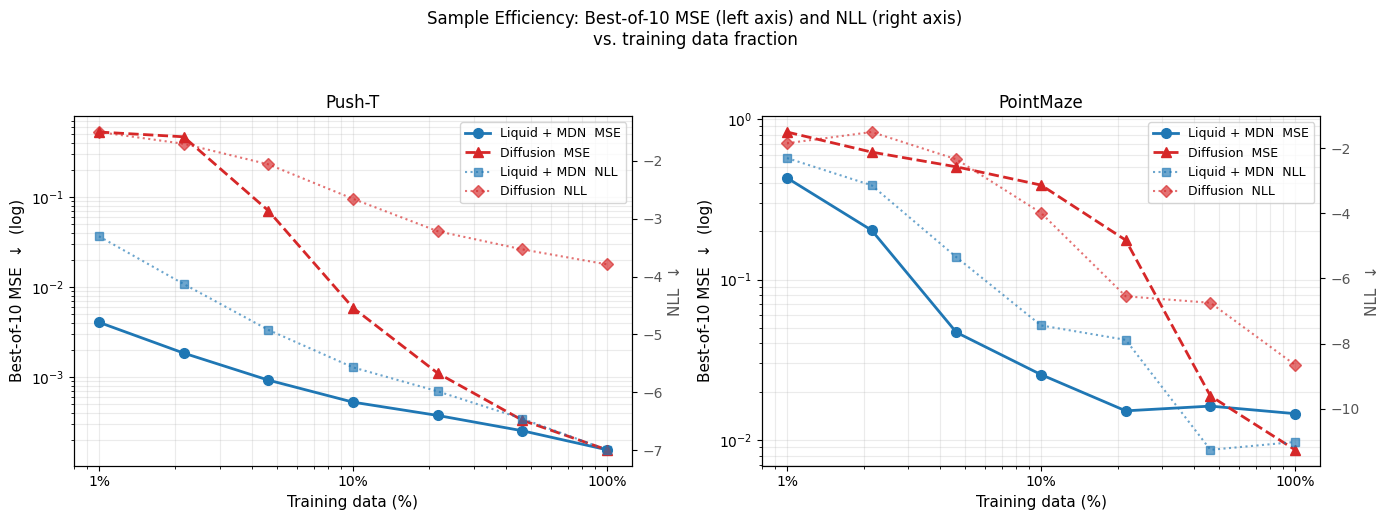

Saved → artifacts/sample_efficiency_combined.pdf


In [5]:
# ── Figure 1: Best-of-10 MSE and NLL vs training fraction (dual y-axis) ─────
COLORS = {'Liquid + MDN': '#1f77b4', 'Diffusion': '#d62728'}
MARKERS = {'Liquid + MDN': 'o', 'Diffusion': '^'}

tasks_ordered = ['Push-T', 'PointMaze']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task_label in zip(axes, tasks_ordered):
    sub = df[df['task'] == task_label].sort_values('fraction')
    ax2 = ax.twinx()

    # ── Left y-axis: Best-of-10 MSE ──────────────────────────────────────────
    l1, = ax.plot(sub['fraction'] * 100, sub['liq_mse_best10'],
                  color=COLORS['Liquid + MDN'], marker='o', lw=2, ms=7,
                  label='Liquid MSE')
    l2, = ax.plot(sub['fraction'] * 100, sub['diff_mse_best10'],
                  color=COLORS['Diffusion'], marker='^', lw=2, ms=7, ls='--',
                  label='Diffusion MSE')

    # ── Right y-axis: NLL ────────────────────────────────────────────────────
    l3, = ax2.plot(sub['fraction'] * 100, sub['liq_nll'],
                   color=COLORS['Liquid + MDN'], marker='s', lw=1.5, ms=6,
                   ls=':', alpha=0.65, label='Liquid NLL')
    l4, = ax2.plot(sub['fraction'] * 100, sub['diff_nll'],
                   color=COLORS['Diffusion'], marker='D', lw=1.5, ms=6,
                   ls=':', alpha=0.65, label='Diffusion NLL')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Training data (%)', fontsize=11)
    ax.set_ylabel('Best-of-10 MSE  ↓  (log)', fontsize=11)
    ax2.set_ylabel('NLL  ↓', fontsize=11, color='#555555')
    ax2.tick_params(axis='y', labelcolor='#555555')

    ax.set_title(f'{task_label}', fontsize=12)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.grid(True, alpha=0.25, which='both')

    lines = [l1, l2, l3, l4]
    labels = ['Liquid + MDN  MSE', 'Diffusion  MSE',
              'Liquid + MDN  NLL', 'Diffusion  NLL']
    ax.legend(lines, labels, fontsize=9, loc='upper right')

plt.suptitle('Sample Efficiency: Best-of-10 MSE (left axis) and NLL (right axis)\nvs. training data fraction',
             fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig(ART / 'sample_efficiency_combined.pdf', bbox_inches='tight')
plt.show()
print('Saved → artifacts/sample_efficiency_combined.pdf')


## 5. Figure 2: Validation-NLL Learning Curves

Per-fraction learning curves (val NLL vs. epoch) for Liquid and Diffusion, faceted by task.  
Output → `artifacts/sample_efficiency_learning_curves.pdf`

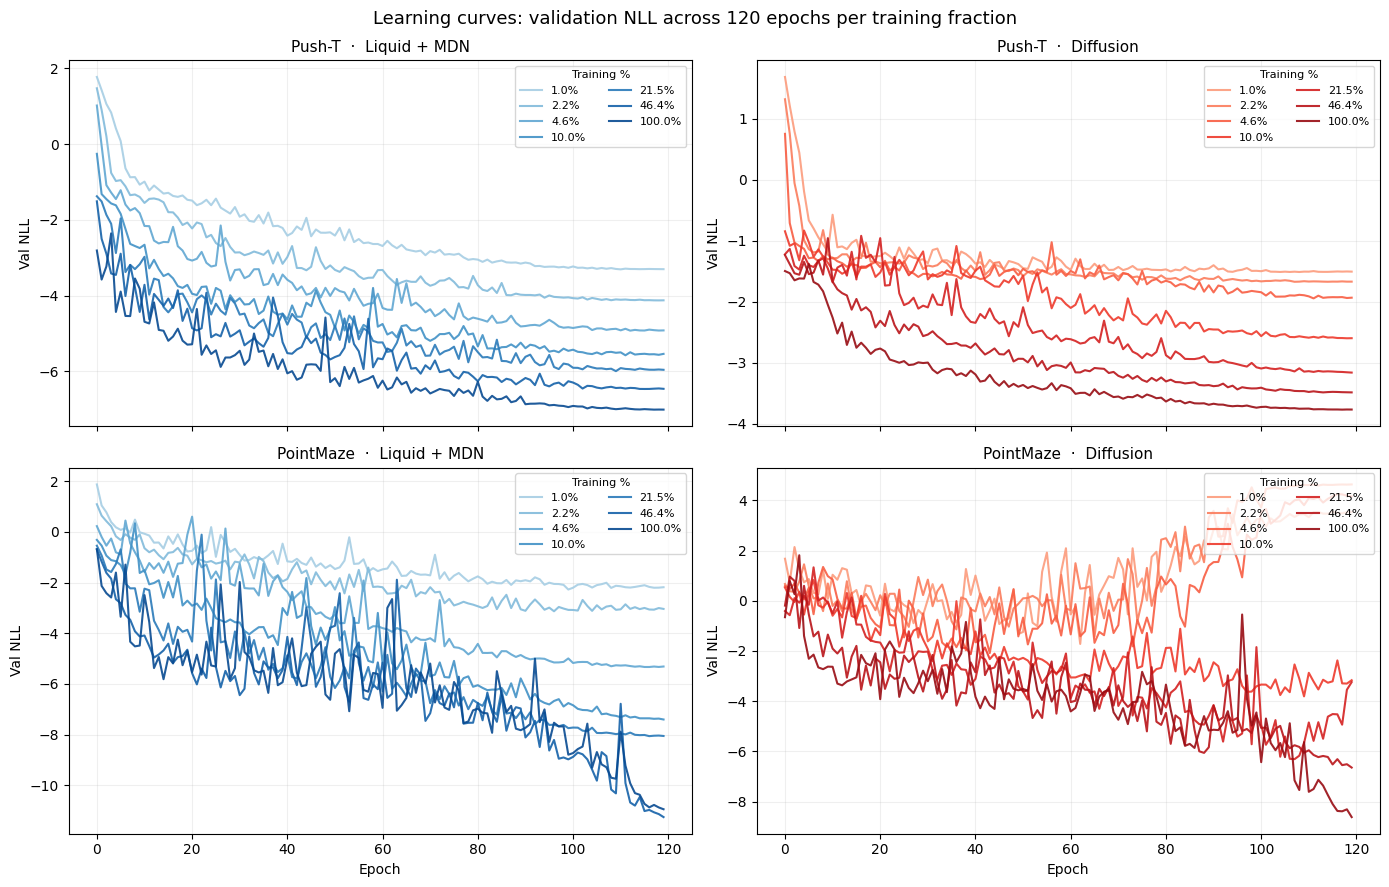

Saved → artifacts/sample_efficiency_learning_curves.pdf


In [6]:
# ── Figure 4: Learning curves — val NLL across 120 epochs per fraction ───────
#   Rows = tasks, Cols = models
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

cmap_liq  = plt.get_cmap('Blues')
cmap_diff = plt.get_cmap('Reds')

hist_tasks = [('pusht', 'Push-T'), ('pointmaze_umaze', 'PointMaze')]
model_cols = [('liquid_val_nll', 'Liquid + MDN', cmap_liq),
              ('diffusion_val_nll', 'Diffusion', cmap_diff)]

n_fracs = len(FRAC_TAGS)

for row_idx, (task_key, task_label) in enumerate(hist_tasks):
    for col_idx, (hist_key, model_label, cmap) in enumerate(model_cols):
        ax = axes[row_idx][col_idx]
        frac_items = [(ft, fv) for ft, fv in FRAC_TAGS.items()
                      if (task_key, ft) in histories]
        frac_items.sort(key=lambda x: x[1])

        for i, (frac_tag, frac_val) in enumerate(frac_items):
            hist = histories[(task_key, frac_tag)]
            epochs = hist.get('epochs', list(range(len(hist[hist_key]))))
            curve  = hist[hist_key]
            color  = cmap(0.35 + 0.55 * (i / max(len(frac_items) - 1, 1)))
            ax.plot(epochs, curve, lw=1.5, alpha=0.9,
                    color=color, label=f'{frac_val*100:.1f}%')

        ax.set_title(f'{task_label}  ·  {model_label}', fontsize=11)
        ax.set_ylabel('Val NLL', fontsize=10)
        ax.grid(True, alpha=0.2)
        leg = ax.legend(title='Training %', fontsize=8, title_fontsize=8,
                        loc='upper right', ncol=2)

for ax in axes[1]:
    ax.set_xlabel('Epoch', fontsize=10)

plt.suptitle('Learning curves: validation NLL across 120 epochs per training fraction',
             fontsize=13)
plt.tight_layout()
plt.savefig(ART / 'sample_efficiency_learning_curves.pdf', bbox_inches='tight')
plt.show()
print('Saved → artifacts/sample_efficiency_learning_curves.pdf')


## 6. Figure 5: PointMaze Closed-Loop Sample Efficiency

Loads `artifacts/sample_efficiency_pointmaze_closedloop_pooled.json` (produced by `02_pointmaze_eval.ipynb`, 40 trials/fraction) and plots success rate vs. training data fraction with ±1 SD error bands.  
Output → `artifacts/sample_efficiency_pointmaze_closedloop.pdf`

PointMaze closed-loop rows available:
 fraction tag  liquid_success_mean  diffusion_success_mean  liquid_dist_mean  diffusion_dist_mean
    0.010                   12.375                  24.500             4.250               13.125
    0.022                   21.750                  26.750             8.250               12.125
    0.046                   39.125                   8.250            15.875                2.500
    0.100                   41.250                  47.750            18.500               22.750
    0.215                   56.500                  27.500            31.625               10.750
    0.464                   25.250                   7.125            11.375                2.125
    1.000                   43.125                  12.250            25.125                5.750


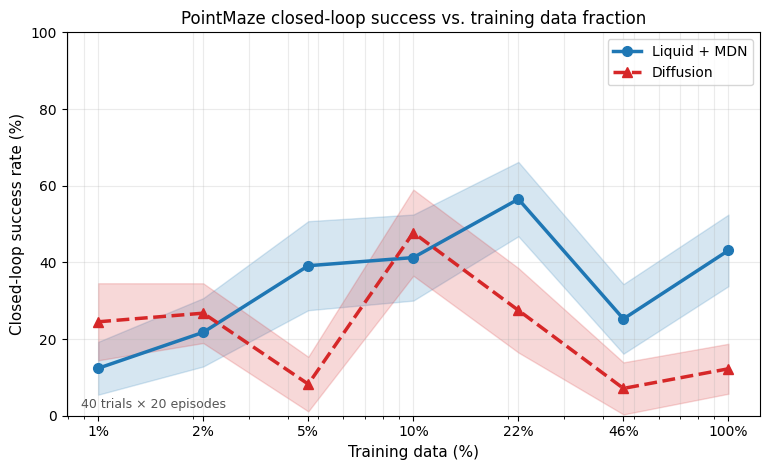

Saved → artifacts/sample_efficiency_pointmaze_closedloop.pdf


In [7]:
# ── Figure 5: PointMaze closed-loop success rate vs. sample efficiency ───────
pm_rows = pd.DataFrame()
pm_plot_rows = pd.DataFrame()

if PM_CLOSEDLOOP.exists():
    with open(PM_CLOSEDLOOP) as f:
        pm_payload = json.load(f)

    pm_rows = pd.DataFrame(pm_payload.get('results', []))

    if not pm_rows.empty:
        pm_rows['tag'] = pm_rows.get('tag', pd.Series('', index=pm_rows.index)).fillna('')
        pm_rows['is_smoke'] = pm_rows['tag'].str.contains('smoketest', na=False)

        # If a real run exists at a given fraction, discard the smoke placeholder for that fraction.
        has_real_at_fraction = pm_rows.groupby('fraction')['is_smoke'].transform(lambda s: (~s).any())
        drop_smoke = pm_rows['is_smoke'] & has_real_at_fraction
        if drop_smoke.any():
            print(
                f"Dropping {drop_smoke.sum()} smoke-test row(s) superseded by full runs: "
                f"{pm_rows.loc[drop_smoke, 'tag'].tolist()}"
            )
        pm_rows = pm_rows.loc[~drop_smoke].copy()

        # If duplicate rows remain at a fraction, prefer non-smoke rows and keep one row/fraction.
        pm_rows = pm_rows.sort_values(['fraction', 'is_smoke', 'tag']).drop_duplicates(
            subset=['fraction'], keep='first'
        )

        def _nested_metric(obj, key):
            if isinstance(obj, dict):
                return obj.get(key, np.nan)
            return np.nan

        for prefix in ['liquid', 'diffusion']:
            pm_rows[f'{prefix}_success_mean'] = pm_rows[prefix].apply(
                lambda x: _nested_metric(x, 'success_rate_mean')
            )
            pm_rows[f'{prefix}_success_std'] = pm_rows[prefix].apply(
                lambda x: _nested_metric(x, 'success_rate_std')
            )
            pm_rows[f'{prefix}_dist_mean'] = pm_rows[prefix].apply(
                lambda x: _nested_metric(x, 'distance_success_rate_mean')
            )
            pm_rows[f'{prefix}_dist_std'] = pm_rows[prefix].apply(
                lambda x: _nested_metric(x, 'distance_success_rate_std')
            )

        pm_rows = pm_rows.sort_values('fraction').reset_index(drop=True)
        pm_plot_rows = pm_rows.loc[~pm_rows['is_smoke']].copy()

        print('PointMaze closed-loop rows available:')
        print(
            pm_rows[[
                'fraction', 'tag',
                'liquid_success_mean', 'diffusion_success_mean',
                'liquid_dist_mean', 'diffusion_dist_mean',
            ]].to_string(index=False, float_format='{:.3f}'.format)
        )

        if pm_plot_rows.empty and pm_rows['is_smoke'].all():
            print(
                '\n[WARN] Only smoke-test rows are present in artifacts/sample_efficiency_pointmaze_closedloop.json.\n'
                '       Figure 5 will not be regenerated until real per-fraction closed-loop runs are saved.'
            )

if PM_CLOSEDLOOP.exists() and len(pm_plot_rows) >= 2:
    frac = pm_plot_rows['fraction'].to_numpy() * 100.0
    liq_sr = pm_plot_rows['liquid_success_mean'].to_numpy(dtype=float)
    liq_sd = pm_plot_rows['liquid_success_std'].to_numpy(dtype=float)
    diff_sr = pm_plot_rows['diffusion_success_mean'].to_numpy(dtype=float)
    diff_sd = pm_plot_rows['diffusion_success_std'].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(7.8, 4.8))
    ax.plot(
        frac, liq_sr, color=COLORS['Liquid + MDN'], marker='o', lw=2.5, ms=7,
        label='Liquid + MDN'
    )
    ax.fill_between(
        frac, np.clip(liq_sr - liq_sd, 0, 100), np.clip(liq_sr + liq_sd, 0, 100),
        color=COLORS['Liquid + MDN'], alpha=0.18
    )
    ax.plot(
        frac, diff_sr, color=COLORS['Diffusion'], marker='^', lw=2.5, ms=7, ls='--',
        label='Diffusion'
    )
    ax.fill_between(
        frac, np.clip(diff_sr - diff_sd, 0, 100), np.clip(diff_sr + diff_sd, 0, 100),
        color=COLORS['Diffusion'], alpha=0.18
    )

    ax.set_xscale('log')
    ax.set_xlabel('Training data (%)', fontsize=11)
    ax.set_ylabel('Closed-loop success rate (%)', fontsize=11)
    ax.set_title('PointMaze closed-loop success vs. training data fraction', fontsize=12)
    ax.set_ylim(0, 100)
    ax.set_xticks(frac)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.grid(True, alpha=0.25, which='both')
    ax.legend(fontsize=10, loc='best')

    if {'trials', 'episodes_per_trial'}.issubset(pm_plot_rows.columns):
        trials = int(pm_plot_rows['trials'].iloc[0])
        episodes_per_trial = int(pm_plot_rows['episodes_per_trial'].iloc[0])
        ax.text(
            0.02, 0.02,
            f'{trials} trials × {episodes_per_trial} episodes',
            transform=ax.transAxes, fontsize=9, color='#555555'
        )

    plt.tight_layout()
    plt.savefig(ART / 'sample_efficiency_pointmaze_closedloop.pdf', bbox_inches='tight')
    plt.show()
    print('Saved → artifacts/sample_efficiency_pointmaze_closedloop.pdf')
else:
    print(
        'PointMaze per-fraction closed-loop results not yet available.\n\n'
        'To generate them, open pointmaze_eval.ipynb and run the\n'
        '"run_pointmaze_sampleeff_closedloop()" cell, which will:\n'
        '  • load each fraction checkpoint pair from the manifest\n'
        '  • run 50 closed-loop trials per checkpoint in PointMaze-UMaze-v3\n'
        '  • write results to artifacts/sample_efficiency_pointmaze_closedloop.json\n\n'
        'Available per-fraction checkpoint pairs:\n'
    )
    for frac_tag, frac_val in FRAC_TAGS.items():
        lq = Path(f'checkpoints/liquid_jepa_pointmaze_umaze_sampleeff_{frac_tag}_{SEED}_best.pt')
        dq = Path(f'checkpoints/diffusion_jepa_pointmaze_umaze_sampleeff_{frac_tag}_{SEED}_best.pt')
        print(f'  {frac_val*100:5.1f}%  liquid={lq.exists()}  diffusion={dq.exists()}')